Import needed libraries and modules

In [10]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.quantum_info import random_unitary
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import mthree

Define the quantum teleportation circuit for qubit and display the quantum circuit

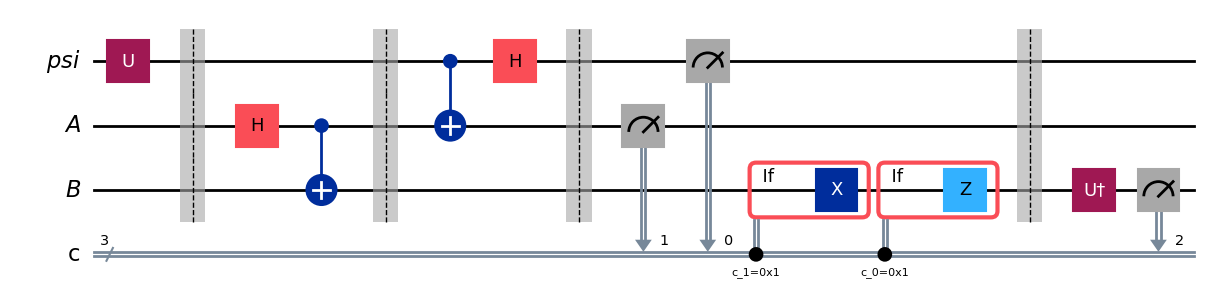

In [11]:
# Define registers and circuit
psi = QuantumRegister(1, "psi")
Alice = QuantumRegister(1, "A")
Bob = QuantumRegister(1, "B")
cr = ClassicalRegister(3, "c")
qc = QuantumCircuit(psi, Alice, Bob, cr)

# We create the unknown state by randomly generating unitary gate and applying it to the |0⟩ state.
U_prep = random_unitary(2, seed=42)
qc.unitary(U_prep, psi, label="U")
qc.barrier()

# We entangle Alice's and Bob's qubits
qc.h(Alice)
qc.cx(Alice, Bob)
qc.barrier()
 
# Now we apply the CNOT and H gates to Alice's qubits
qc.cx(psi, Alice)
qc.h(psi)
qc.barrier()
 
# Now Alice measures her qubits
qc.measure(Alice, cr[1])
qc.measure(psi, cr[0])
 
# We apply the necessary gates to Bob's qubit based on Alice's measurement results
with qc.if_test((cr[1], 1)):
    qc.x(Bob)
with qc.if_test((cr[0], 1)):
    qc.z(Bob)
qc.barrier()
 
# Finally, we apply the inverse of u to Bob's qubit and measure for verification of the teleportation
qc.unitary(U_prep.adjoint(), Bob, label="U†")
qc.measure(Bob, cr[2])
 
fig = qc.draw(output="mpl", fold=100)
fig.savefig("results/circuit_qubit.png", dpi=600, bbox_inches="tight")
display(fig)

Run the teleportation protocol on real quantum hardware the IBM Kingston

In [4]:
# Initialize runtime service and backend
service = QiskitRuntimeService()
backend = service.backend("ibm_kingston")
# Optimize circuit for backend
pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)
# Run circuit using Sampler
sampler = SamplerV2(mode=backend)
job = sampler.run([qc_isa])
res = job.result()

Process measurement counts and plot teleportation outcomes.

Probability of 0 on qubit 2: 0.9602


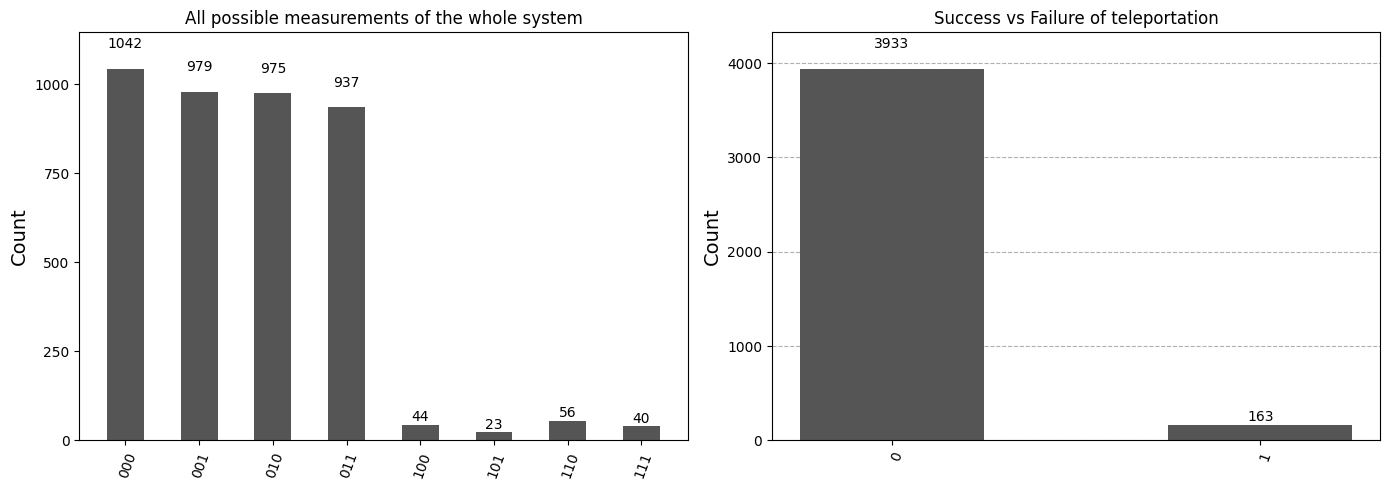

In [5]:
counts = res[0].data.c.get_counts()
filtered_statistics = marginal_counts(counts, [2])

total_shots = sum(filtered_statistics.values())
prob_0 = filtered_statistics.get('0', 0) / total_shots
print(f"Probability of 0 on qubit 2: {prob_0:.4f}")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot full counts
plot_histogram(counts, ax=ax1, color='#555555')
ax1.set_title("All possible measurements of the whole system")

# Plot marginal counts
plot_histogram(filtered_statistics, ax=ax2, color='#555555')
ax2.set_title("Success vs Failure of teleportation")

plt.tight_layout()
fig.savefig("results/qubit_kingston_result.png", dpi=600)
plt.show()

Run the M3Mitigation on the result of the teleportation protocol

In [6]:
mit = mthree.M3Mitigation(backend)

qubit_mapping = mthree.utils.final_measurement_mapping(qc_isa)
qubit_list = [qubit_mapping[i] for i in sorted(qubit_mapping)]

# calibration using the ordered physical qubits
mit.cals_from_system(qubit_list)

# apply mitigation
counts = res[0].data.c.get_counts()
quasi = mit.apply_correction(counts, qubit_list)
print(quasi)

{'000': np.float32(0.25603577), '001': np.float32(0.23778005), '010': np.float32(0.24281278), '011': np.float32(0.23078763), '100': np.float32(0.0088145435), '101': np.float32(0.0036511766), '110': np.float32(0.01208671), '111': np.float32(0.008031281)}


Plot the mitigated result to the raw counts.

--- Teleportation Success Metric ---
Raw:       0.9602
Mitigated: 0.9674
Improvement: +0.72%


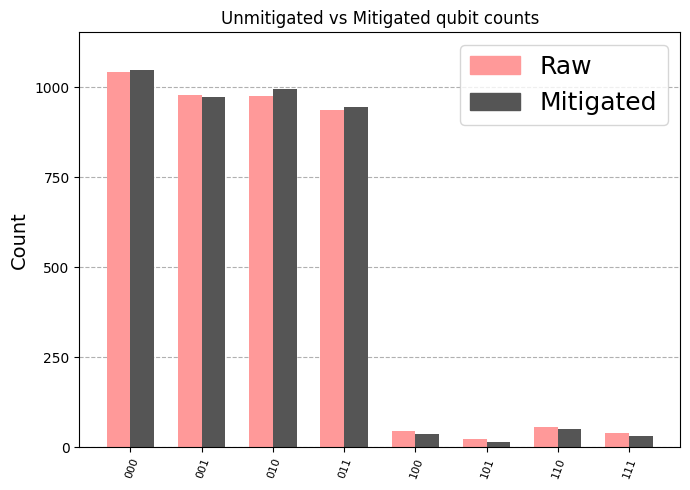

In [9]:
probs = quasi.nearest_probability_distribution()
mitigated_probs = {k: v for k, v in probs.items()}
mitigated_filtered_statistics = marginal_counts(mitigated_probs, [2])

raw_success = filtered_statistics['0'] / total_shots
mitigated_success = mitigated_filtered_statistics['0']

print("--- Teleportation Success Metric ---")
print(f"Raw:       {raw_success:.4f}")
print(f"Mitigated: {mitigated_success:.4f}")
print(f"Improvement: {(mitigated_success - raw_success) * 100:+.2f}%")

mitigated_counts_for_plot = {k: v * total_shots for k, v in mitigated_probs.items()}

fig, ax = plt.subplots(figsize=(7, 5))

plot_histogram(
    [counts, mitigated_counts_for_plot],
    legend=['Raw', 'Mitigated'],
    color=['#ff9999', '#555555'],
    title="Unmitigated vs Mitigated qubit counts",
    bar_labels=False,
    ax=ax
)

raw_patch = mpatches.Patch(color='#ff9999', label='Raw')
mit_patch = mpatches.Patch(color='#555555', label='Mitigated')
ax.legend(handles=[raw_patch, mit_patch], loc='upper right', fontsize=18)

ax.tick_params(axis='x', rotation=70, labelsize=8)
plt.tight_layout()
fig.savefig("results/qubit_mitigated.png", dpi=600)
plt.show()